In [39]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics.club import CLUBS
from pangya_physics.wind import Wind
from pangya_physics.solver import find_power

In [41]:
import inspect

print(inspect.signature(Wind))

(speed: float, degree: float) -> None


In [42]:
wind = Wind(0, 0)

In [43]:
clubs = [
    {"name": name, "info": info}
    for name, info in CLUBS.items()
]

len(clubs)

13

In [44]:
target_distances = list(range(50, 351, 10))

target_distances[:5]

[50, 60, 70, 80, 90]

In [45]:
results = []

for club in clubs:

    for target_distance in target_distances:

        try:

            result = find_power(
                club=club["info"],
                wind=wind,
                target_distance=target_distance,
                target_height=0.0,
            )

            results.append({
                "club": club["name"],
                "club_type": club["info"].club_type.value,
                "target_distance": target_distance,
                "power_percent": result.power_percent,
                "power_range": result.power_range,
                "final_distance": result.final_distance,
                "error": result.error,
                "abs_error": abs(result.error),
                "iterations": result.iterations,
                "found": result.found,
                "reachable": result.reachable,
            })

        except Exception as e:

            results.append({
                "club": club["name"],
                "club_type": club["info"].club_type.value,
                "target_distance": target_distance,
                "status": str(e),
            })

df = pd.DataFrame(results)

df.head()

,club,club_type,target_distance,power_percent,power_range,final_distance,error,abs_error,iterations,found,reachable
0,1W,wood,50,0.310938,71.515625,49.729930,0.270070,0.270070,8,True,True
1,1W,wood,60,0.343750,79.062500,60.493727,-0.493727,0.493727,6,True,True
2,1W,wood,70,0.371875,85.531250,69.761391,0.238609,0.238609,7,True,True
3,1W,wood,80,0.400000,92.000000,79.559358,0.440642,0.440642,2,True,True
4,1W,wood,90,0.428125,98.468750,89.857723,0.142277,0.142277,7,True,True


In [46]:
df_valid = df[
    (df["found"] == True) &
    (df["reachable"] == True) &
    (df["power_percent"] <= 1.0)
].copy()

len(df_valid)

282

In [47]:
summary = df_valid.groupby("club").agg(
    min_distance=("target_distance", "min"),
    max_distance=("target_distance", "max"),
    avg_abs_error=("abs_error", "mean"),
    max_abs_error=("abs_error", "max"),
    avg_iterations=("iterations", "mean"),
).reset_index()

summary.sort_values("max_distance", ascending=False)

,club,min_distance,max_distance,avg_abs_error,max_abs_error,avg_iterations
0,1W,50,340,0.357970,0.497257,7.782609
2,2W,50,330,0.315759,0.489845,7.714286
1,2I,50,310,0.269870,0.483223,8.333333
4,3W,50,310,0.287092,0.484562,7.958333
3,3I,50,300,0.284440,0.498410,9.041667
5,4I,50,300,0.332069,0.496239,7.807692
6,5I,50,280,0.253131,0.493685,7.666667
7,6I,50,280,0.245728,0.496898,8.260870
8,7I,50,260,0.287521,0.497197,8.045455
9,8I,50,250,0.263130,0.479301,8.428571


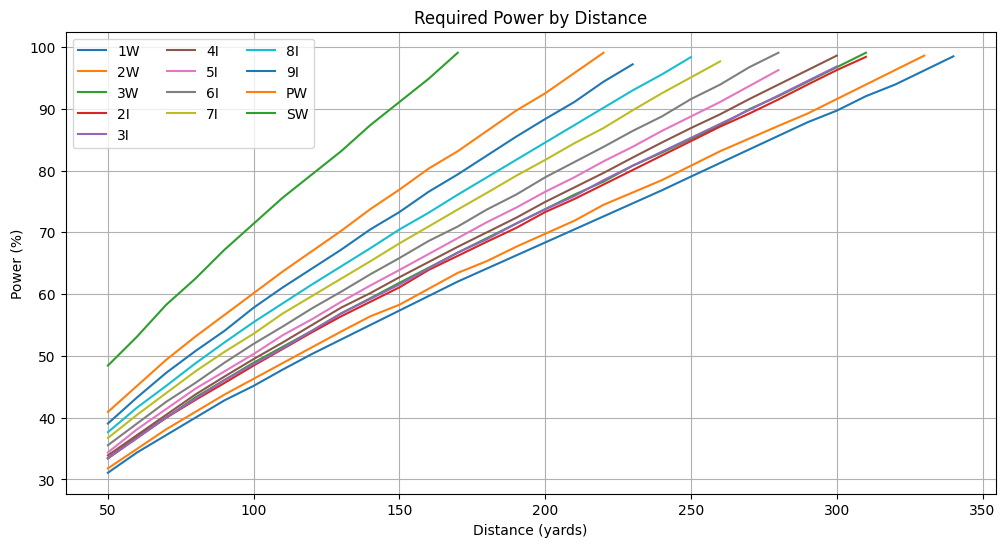

In [48]:
plt.figure(figsize=(12, 6))

for club in df_valid["club"].unique():

    club_df = df_valid[df_valid["club"] == club]

    plt.plot(
        club_df["target_distance"],
        club_df["power_percent"] * 100,
        label=club
    )

plt.title("Required Power by Distance")
plt.xlabel("Distance (yards)")
plt.ylabel("Power (%)")
plt.grid(True)
plt.legend(ncol=3)

plt.show()

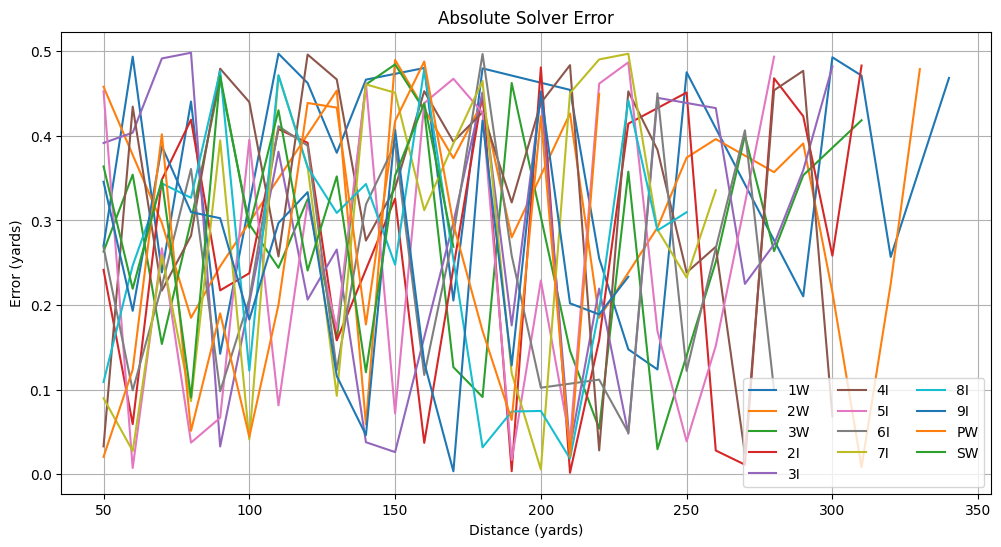

In [49]:
plt.figure(figsize=(12, 6))

for club in df_valid["club"].unique():

    club_df = df_valid[df_valid["club"] == club]

    plt.plot(
        club_df["target_distance"],
        club_df["abs_error"],
        label=club
    )

plt.title("Absolute Solver Error")
plt.xlabel("Distance (yards)")
plt.ylabel("Error (yards)")
plt.grid(True)
plt.legend(ncol=3)

plt.show()

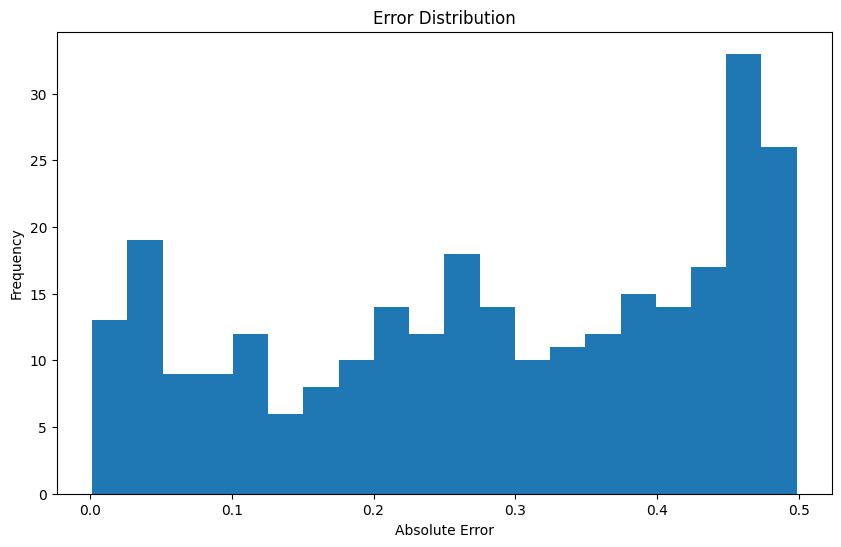

In [50]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_valid["abs_error"],
    bins=20
)

plt.title("Error Distribution")
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")

plt.show()

In [51]:
club_ranges = (
    df_valid.groupby("club")["target_distance"]
    .max()
    .sort_values(ascending=False)
)

club_ranges

club
1W    340
2W    330
2I    310
3W    310
3I    300
4I    300
5I    280
6I    280
7I    260
8I    250
9I    230
PW    220
SW    170
Name: target_distance, dtype: int64

In [52]:
output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "club_dataset_analysis.csv"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

df_valid.to_csv(
    output_path,
    index=False
)

output_path

WindowsPath('c:/Users/felip/OneDrive/Documentos/Nova pasta/pangya-shot-physics/data/processed/club_dataset_analysis.csv')